In [1]:
# coverage_statistics.ipynb

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import sys
from sccnasim.xlib.xdata import load_10x_data

In [3]:
base_dir = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/cna_prediction/1n1t_s1600/downsample_ref/ds_600/gen_data/matrix'

ds_root_dir = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/cna_prediction/1n1t_s1600/downsample_coverage'
ds_perc_list = [50, 20, 10, 5, 3]    # decending order.
ds_dir_list = [os.path.join(ds_root_dir, 'ds_%dperc/gen_data/rdr_starsolo' % i) for i in ds_perc_list]

out_dir = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/cna_prediction/1n1t_s1600/downsample_coverage/analysis/coverage_statistics'

In [4]:
utils_dir = out_dir
sys.path.append(utils_dir)
from ubase import *
from urdr import *

# Load data

In [5]:
perc_list = [100] + ds_perc_list
dir_list = [base_dir] + ds_dir_list
id_list = ['%d' % i for i in perc_list]

id_list

['100', '50', '20', '10', '5', '3']

In [6]:
adata_list = []
for data_id, mat_dir in zip(id_list, dir_list):
    print("processing '%s' ..." % data_id)
    adata = load_10x_data(mat_dir)
    print(adata)
    adata_list.append(adata)

processing '100' ...
AnnData object with n_obs × n_vars = 1600 × 33538
    obs: 'cell'
    var: 'feature_id', 'feature_name'
processing '50' ...


/home/xianjie/.anaconda3/envs/SCSC/lib/python3.11/site-packages/anndata-0.10.7-py3.11.egg/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/xianjie/.anaconda3/envs/SCSC/lib/python3.11/site-packages/anndata-0.10.7-py3.11.egg/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/xianjie/.anaconda3/envs/SCSC/lib/python3.11/site-packages/anndata-0.10.7-py3.11.egg/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/xianjie/.anaconda3/envs/SCSC/lib/python3.11/site-packages/anndata-0.10.7-py3.11.egg/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificat

AnnData object with n_obs × n_vars = 1600 × 33538
    obs: 'cell'
    var: 'feature_id', 'feature_name'
processing '20' ...
AnnData object with n_obs × n_vars = 1600 × 33538
    obs: 'cell'
    var: 'feature_id', 'feature_name'
processing '10' ...


/home/xianjie/.anaconda3/envs/SCSC/lib/python3.11/site-packages/anndata-0.10.7-py3.11.egg/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/xianjie/.anaconda3/envs/SCSC/lib/python3.11/site-packages/anndata-0.10.7-py3.11.egg/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/xianjie/.anaconda3/envs/SCSC/lib/python3.11/site-packages/anndata-0.10.7-py3.11.egg/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/xianjie/.anaconda3/envs/SCSC/lib/python3.11/site-packages/anndata-0.10.7-py3.11.egg/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificat

AnnData object with n_obs × n_vars = 1600 × 33538
    obs: 'cell'
    var: 'feature_id', 'feature_name'
processing '5' ...
AnnData object with n_obs × n_vars = 1600 × 33538
    obs: 'cell'
    var: 'feature_id', 'feature_name'
processing '3' ...
AnnData object with n_obs × n_vars = 1600 × 33538
    obs: 'cell'
    var: 'feature_id', 'feature_name'


/home/xianjie/.anaconda3/envs/SCSC/lib/python3.11/site-packages/anndata-0.10.7-py3.11.egg/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/xianjie/.anaconda3/envs/SCSC/lib/python3.11/site-packages/anndata-0.10.7-py3.11.egg/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


# Cell-wise metrics

In [7]:
cw_prefix = 'cw-'

In [8]:
mv = get_cw_metrics_group(
    X_lst = [adata.X for adata in adata_list],
    X_names = id_list,
    id_lst = [adata.obs['cell'].to_numpy() for adata in adata_list],
    metrics = ["lib_size", "zero_prop"]
)
mv = mv.rename(columns = dict(X_name = 'group'))
mv

,lib_size,zero_prop,group,cell
0,5583,0.942364,100,AAACCTGAGACCACGA-1
1,14142,0.899577,100,AAACCTGCAAGTAGTA-1
2,18989,0.881627,100,AAACCTGTCAGCGATT-1
3,6351,0.937683,100,AAACGGGAGGTAGCTG-1
4,8977,0.923877,100,AAACGGGGTATTAGCC-1
...,...,...,...,...
9595,1106,0.981215,3,TTTGGTTGTGCTCTTC-1
9596,947,0.984167,3,TTTGTCAAGGCTAGAC-1
9597,604,0.988580,3,TTTGTCACACAGCCCA-1
9598,737,0.986523,3,TTTGTCACATCGTCGG-1


In [9]:
tmp = mv[["group", "cell", "lib_size", "zero_prop"]]

tmp.to_csv(
    os.path.join(out_dir, cw_prefix + "metric_values.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

In [10]:
sns.set_palette("colorblind")
palette = sns.color_palette("colorblind")
palette

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [11]:
def_color = palette[0]

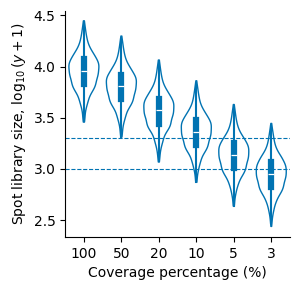

In [12]:
fig = plt.figure(figsize = (3.1, 3))

x = mv['group']
y = mv['lib_size']
y = np.log10(y + 1)
ax = sns.violinplot(
    x = x, y = y, 
    fill = False, 
    palette = [def_color] * 6, 
    hue = x, 
    legend = False,
    inner = 'box',
    cut = 0,
    linewidth = 1.0
)
ax.axhline(y = np.log10(1000 + 1), linestyle = '--', linewidth = 0.8)
ax.axhline(y = np.log10(2000 + 1), linestyle = '--', linewidth = 0.8)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(
    ax.get_xticklabels(), 
    #rotation = 45, rotation_mode = "anchor", ha = 'right'
)
ax.set_xlabel("Coverage percentage (%)")
ax.set_ylabel(r"Spot library size, $\log_{10}(y+1)$")
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)

plt.tight_layout()
fn = os.path.join(out_dir, cw_prefix + "libsize.png")
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')

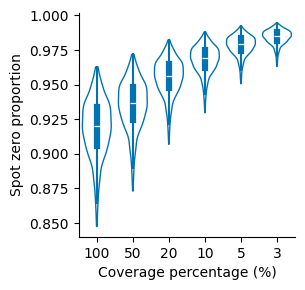

In [13]:
fig = plt.figure(figsize = (3.15, 3))

x = mv['group']
y = mv['zero_prop']
ax = sns.violinplot(
    x = x, y = y, 
    fill = False, 
    palette = [def_color] * 6, 
    hue = x, 
    legend = False,
    inner = 'box',
    cut = 0,
    linewidth = 1.0
)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(
    ax.get_xticklabels()
)
#ax.set_yticks((0.85, 0.9, 0.95, 1.0))
#ax.set_yticklabels([str(y) for y in (0.85, 0.9, 0.95, 1.0)])
ax.set_xlabel("Coverage percentage (%)")
ax.set_ylabel("Spot zero proportion")
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)

plt.tight_layout()
fn = os.path.join(out_dir, cw_prefix + "zero_prop.png")
fig.savefig(fn, dpi = 300, bbox_inches = 'tight')